# Steps to Perform

## EDA - Answer at least 3 of the following questions:
- NOTE: Some of these may require preprocessing found in Step 2.
- Do reviewers use punctuation correctly?
- Does the number of spelling errors differ by rating?
- What is the distribution of star ratings across products?
- How does review length differ by rating?
- How long is the typical review?
- What is the frequency of words with spelling errors by rating?
- What is the number of reviews that don’t end sentences with punctuation?
- What is the proportion of reviews with spelling errors?

## Preprocess the dataset by :
- Generating a binary target variable from ratings (positive / negative sentiment)
- Clean the Data - Common NLP Data Cleaning Techniques - 
    - Normalizing the Texts ("Héllò hôw are ü?" --> "Hello how are u?")
    - Removing stop-words ("The black cat is a menace." ---> "black cat is menace.")
    - Stemming words ("Writting" ---> "write")
    - Lemmatizing words ("Better" ---> "good")
    - Padding (allows for consistent vector size)
- Tokenize the Text Data - Assigns each word a unique Token.
- Could use https://huggingface.co/docs/tokenizers/indexLinks to an external site.
- `pip install tokenizers` 
- Or research another method for tokenizing your texts
- Divide the data into Training and Testing Sets

## Design a custom CNN-RNN hybrid model combining Convolutional,  Recurrent, and Dense blocks in order to predict the rating of a review. 
- Block 1 : 
    - Conv1D, MaxPooling, etc...
    - Feel free to experiment here, to see what works best,
- Block 2 : 
    - RNN, LSTM, or GRU layer
- Block 3 :
    - Dense Layers

4. Train, Evaluate and Discuss the model. 
- Choose a metric to evaluate your model
- Create Confusion Matrices
- Discuss:
    - EDA
    - Data Preprocessing
    - Model Architecture Decisions
    - Training metrics
    - Final model performance

In [1]:
# Installs
%pip install --quiet scipy matplotlib seaborn scikit-learn pandas pyspellchecker tokenizers requests transformers

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Imports
import re
import spellchecker
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import requests
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tokenizers import BertWordPieceTokenizer
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


#Load csv dataset into pandas dataframe
reviews_df = pd.read_csv('https://gperdrizet.github.io/FSA_devops/assets/data/unit4/GrammarandProductReviews.csv')
#Show first 5 rows of dataframe
print(reviews_df.head())
#Show summary statistics of dataframe
print(reviews_df.describe())
#Show number of rows and columns in dataframe
print(reviews_df.shape)


/home/rpetras/github/FSA_devops/.venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


                     id            brand  \
0  AV13O1A8GV-KLJ3akUyj  Universal Music   
1  AV14LG0R-jtxr-f38QfS         Lundberg   
2  AV14LG0R-jtxr-f38QfS         Lundberg   
3  AV16khLE-jtxr-f38VFn              K-Y   
4  AV16khLE-jtxr-f38VFn              K-Y   

                                          categories             dateAdded  \
0  Movies, Music & Books,Music,R&b,Movies & TV,Mo...  2017-07-25T00:52:42Z   
1  Food,Packaged Foods,Snacks,Crackers,Snacks, Co...  2017-07-25T05:16:03Z   
2  Food,Packaged Foods,Snacks,Crackers,Snacks, Co...  2017-07-25T05:16:03Z   
3  Personal Care,Medicine Cabinet,Lubricant/Sperm...  2017-07-25T16:26:19Z   
4  Personal Care,Medicine Cabinet,Lubricant/Sperm...  2017-07-25T16:26:19Z   

            dateUpdated          ean  \
0  2018-02-05T08:36:58Z  6.02537E+11   
1  2018-02-05T11:27:45Z  73416000391   
2  2018-02-05T11:27:45Z  73416000391   
3  2018-02-05T11:25:51Z  67981934427   
4  2018-02-05T11:25:51Z  67981934427   

                         

In [3]:
# Drop columns that are not going to be useful in analytics
# ean, reviews.id, reviews.username, manufacturerNumber, keys, upc, reviews.didPurchase
slimmed_reviews_df = reviews_df.drop(columns=['ean',
                                      'manufacturer',
                                      'brand',
                                      'categories',
                                      'name',
                                      'dateAdded',
                                      'dateUpdated',
                                      'reviews.date',
                                      'reviews.dateSeen',
                                      'reviews.dateAdded',
                                      'reviews.sourceURLs',
                                      'reviews.id',
                                      'reviews.username',
                                      'reviews.userCity',
                                      'reviews.userProvince',
                                      'manufacturerNumber',
                                      'keys',
                                      'upc',
                                      'reviews.didPurchase'])
# Purchasing information might be seen as important, but since we are classifying sentiment, it can be disregarded as a negative review
# from someone who did not buy it shows enough sentiment towards a product to allow the view to be influenced. Even in the case of
# review-bombing a product, the sentiment is still applicable and should be classified.
# Show number of rows and columns in dataframe after dropping columns and look at number of NaN entries per column to see where data is missing
print(slimmed_reviews_df.shape)
print(slimmed_reviews_df.isna().sum())
# Show summary statistics of dataframe after dropping columns
print(slimmed_reviews_df.describe())
print(slimmed_reviews_df.info())
# Print the first 5 values in each column
for column in slimmed_reviews_df.columns:
    print(f"{column}:\n{slimmed_reviews_df[column].head()}\n")


(71044, 6)
id                         0
reviews.doRecommend    10615
reviews.numHelpful     38536
reviews.rating             0
reviews.text              36
reviews.title            477
dtype: int64
       reviews.numHelpful  reviews.rating
count        32508.000000    71044.000000
mean             0.410422        4.385747
std              3.574442        1.067659
min              0.000000        1.000000
25%              0.000000        4.000000
50%              0.000000        5.000000
75%              0.000000        5.000000
max            183.000000        5.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71044 entries, 0 to 71043
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   71044 non-null  object 
 1   reviews.doRecommend  60429 non-null  object 
 2   reviews.numHelpful   32508 non-null  float64
 3   reviews.rating       71044 non-null  int64  
 4   reviews.tex

In [4]:
# After slimming the df down to 6 columns we can start cleaning it up and make it faster and easier to process and classify
# doRecommend has 3 states: true, false and NaN. This can be interepreted as a -1, 0 and 1 respectively, where -1 is a
# negative review, 0 is a neutral review and 1 is a positive review. This allows us to weight the sentiment a little better
def convert_recommendation(value):
    if value == True:
        return 1
    elif value == False:
        return -1
    else:
        return 0
slimmed_reviews_df['reviews.doRecommend'] = slimmed_reviews_df['reviews.doRecommend'].apply(convert_recommendation)
# Show the number of reviews that are positive, negative and neutral
print(slimmed_reviews_df['reviews.doRecommend'].value_counts())

reviews.doRecommend
 1    55587
 0    10615
-1     4842
Name: count, dtype: int64


In [5]:
# print numHelpful values
print(slimmed_reviews_df['reviews.numHelpful'].value_counts())
# None of these are actually floating point numbers so we can convert them to smaller integers to save space and make processing faster
# Set NaN values to 0 and convert to lowest integer type
slimmed_reviews_df['reviews.numHelpful'] = slimmed_reviews_df['reviews.numHelpful'].fillna(0).astype(np.uint8)
print(slimmed_reviews_df['reviews.numHelpful'].value_counts())
# This column can be used as a multiplier to increase sentiment in either a positive or negative direction

reviews.numHelpful
0.0      29596
1.0       1384
2.0        422
3.0        324
4.0        210
         ...  
115.0        1
67.0         1
183.0        1
30.0         1
37.0         1
Name: count, Length: 72, dtype: int64
reviews.numHelpful
0      68132
1       1384
2        422
3        324
4        210
       ...  
115        1
67         1
183        1
30         1
37         1
Name: count, Length: 72, dtype: int64


In [6]:
# Convert all NaN values in reviews.rating to 0 and convert to lowest integer type
slimmed_reviews_df['reviews.rating'] = slimmed_reviews_df['reviews.rating'].fillna(0).astype(np.uint8)
print(slimmed_reviews_df['reviews.rating'].value_counts())

reviews.rating
5    46543
4    14598
3     4369
1     3701
2     1833
Name: count, dtype: int64


In [7]:
# Fill NaNs with empty strings
slimmed_reviews_df['reviews.text'] = slimmed_reviews_df['reviews.text'].fillna('')
# Analyze the reviews.text values to find spelling errors
spell = spellchecker.SpellChecker()
def count_spelling_errors(text):
    words = re.findall(r'\b\w+\b', text.lower())
    misspelled = spell.unknown(words)
    return len(misspelled)
# Apply the function to the reviews.text column and create a new column called spelling_errors
slim_spell_reviews_df = slimmed_reviews_df.copy()
slim_spell_reviews_df['spelling_errors'] = slimmed_reviews_df['reviews.text'].apply(count_spelling_errors)
# Bin spelling errors into 5 categories: 0, 1-5, 6-10, 11-15, and 16+
def bin_spelling_errors(errors):
    if errors == 0:
        return '0'
    elif errors <= 5:
        return '1-5'
    elif errors <= 10:
        return '6-10'
    elif errors <= 15:
        return '11-15'
    else:
        return '16+'
slim_spell_reviews_df['spelling_errors'] = slim_spell_reviews_df['spelling_errors'].apply(bin_spelling_errors)
# Show the number of spelling errors in the reviews
print(slim_spell_reviews_df['spelling_errors'].value_counts())

spelling_errors
0        44020
1-5      26628
6-10       349
11-15       33
16+         14
Name: count, dtype: int64


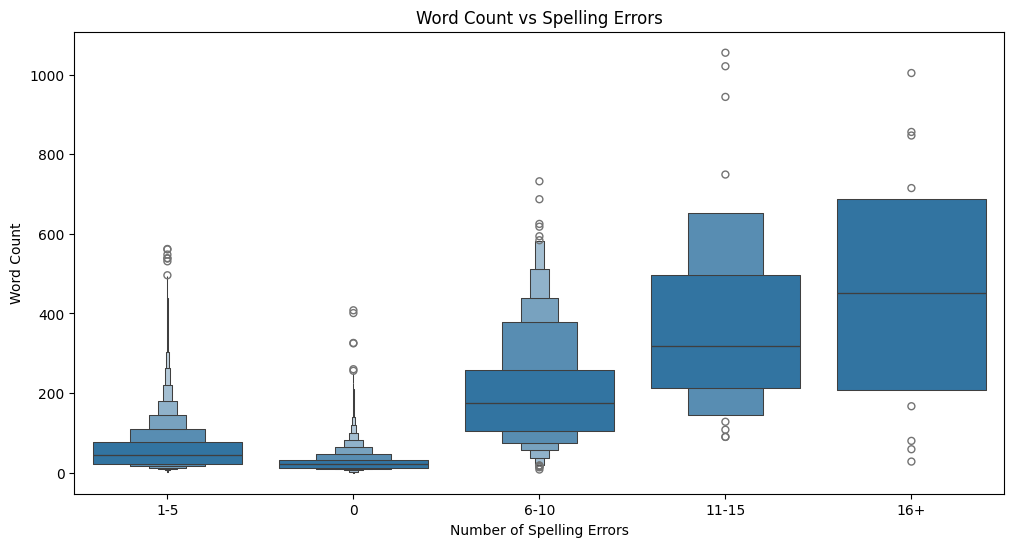

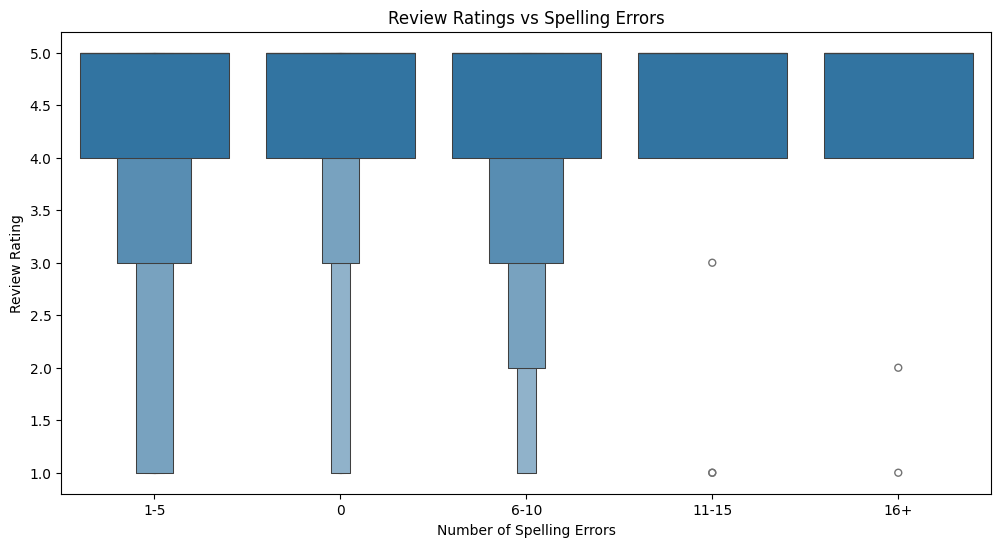

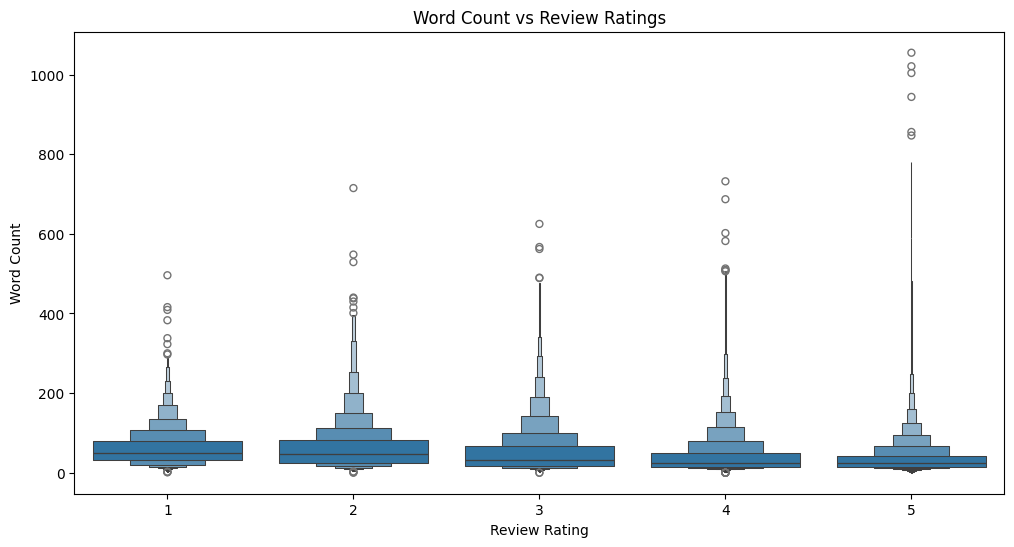

<Figure size 1200x600 with 0 Axes>

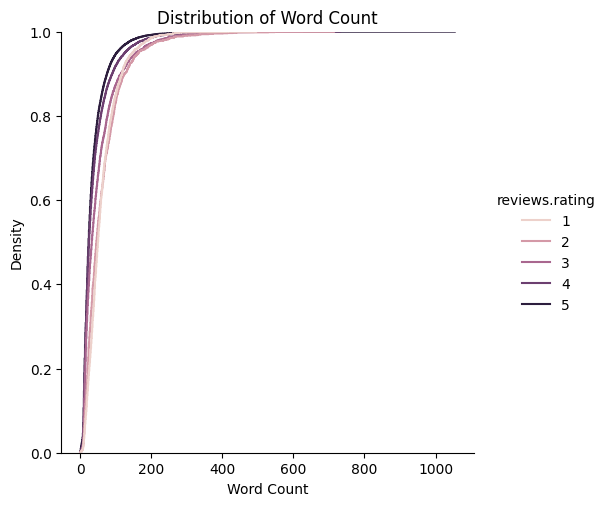

reviews.rating
1    61.154012
2    63.094926
3    51.881895
4    41.081244
5    36.156479
Name: word_count, dtype: float64
reviews.rating  spelling_errors
1               1-5                0.534450
                0                  0.459876
                6-10               0.004864
                11-15              0.000540
                16+                0.000270
2               1-5                0.537916
                0                  0.452810
                6-10               0.008729
                16+                0.000546
3               0                  0.501946
                1-5                0.487755
                6-10               0.010071
                11-15              0.000229
4               0                  0.605151
                1-5                0.387998
                6-10               0.006165
                11-15              0.000411
                16+                0.000274
5               0                  0.654470
         

In [8]:
# plot the word counts and per spelling errors and the review ratings per spelling errors on two charts so we can see the spread
# Create a new column for word count
slim_spell_reviews_df['word_count'] = slim_spell_reviews_df['reviews.text'].apply(lambda x: len(re.findall(r'\b\w+\b', x)))

# Plot word count vs spelling errors
plt.figure(figsize=(12, 6))
sns.boxenplot(data=slim_spell_reviews_df, x='spelling_errors', y='word_count')
plt.title('Word Count vs Spelling Errors')
plt.xlabel('Number of Spelling Errors')
plt.ylabel('Word Count')
plt.show()

# Plot review ratings vs spelling errors
plt.figure(figsize=(12, 6))
sns.boxenplot(data=slim_spell_reviews_df, x='spelling_errors', y='reviews.rating')
plt.title('Review Ratings vs Spelling Errors')
plt.xlabel('Number of Spelling Errors')
plt.ylabel('Review Rating')
plt.show()

# Plot word count vs review ratings
plt.figure(figsize=(12, 6))
sns.boxenplot(data=slim_spell_reviews_df, x='reviews.rating', y='word_count')
plt.title('Word Count vs Review Ratings')
plt.xlabel('Review Rating')
plt.ylabel('Word Count')
plt.show()

# plot displot for word count and review ratings
plt.figure(figsize=(12, 6))
sns.displot(data=slim_spell_reviews_df, x='word_count', hue='reviews.rating', kind='ecdf')
plt.title('Distribution of Word Count')
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.show()

# print the average word count for each review rating
print(slim_spell_reviews_df.groupby('reviews.rating')['word_count'].mean())
# print the average spelling error bin amount per review rating
print(slim_spell_reviews_df.groupby('reviews.rating')['spelling_errors'].value_counts(normalize=True))

# Notes so far
- Removing lots of extraneous categories helped narrow our focus onto the things that will actually help in the classifying of our sentiment
- Using the doRecommend column as a weight towards negative or positive bias is a lot easier after conversion to -1,0,1 values instead of False, NaN, True.
- The reviews.amountHelpful is also a good multiplier of sentiment, where it can make a lower confidence sentiment much higher in confidence if a lot of others found it helpful and/or agreeable
## Spleling Erorrs and word counts effects on ratings
- On average, the better reviews have shorter word counts
    - However, the longest reviews are still under the 5* ratings
- Higher ratings had lower spelling errors on average and lower ratings had higer amounts of spelling errors
    - 2* reviews had the most spelling errors per capita, which is kind of interesting

In [9]:
# Generate a binary sentiment target based on the rating 4-5 is positive or 1, 1-3 is negative or 0.
def generate_sentiment_target(rating):
    if rating >= 4:
        return 1
    elif rating >= 1:
        return 0
    else:
        return np.nan
    
slimmed_reviews_df['sentiment'] = slimmed_reviews_df['reviews.rating'].apply(generate_sentiment_target)
# Show the number of positive and negative reviews
print(slimmed_reviews_df['sentiment'].value_counts())

# Convert all dtypes into their smallest possible types to save space and make processing faster
slimmed_reviews_df['reviews.doRecommend'] = slimmed_reviews_df['reviews.doRecommend'].astype(np.int8)
slimmed_reviews_df['sentiment'] = slimmed_reviews_df['sentiment'].astype(np.int8)
print(slimmed_reviews_df.info())
# Save this cleaned dataframe to a new csv file as a checkpoint and to use in the next steps of the project
slimmed_reviews_df.to_csv('cleaned_reviews.csv', index=False)

sentiment
1    61141
0     9903
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71044 entries, 0 to 71043
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   71044 non-null  object
 1   reviews.doRecommend  71044 non-null  int8  
 2   reviews.numHelpful   71044 non-null  uint8 
 3   reviews.rating       71044 non-null  uint8 
 4   reviews.text         71044 non-null  object
 5   reviews.title        70567 non-null  object
 6   sentiment            71044 non-null  int8  
dtypes: int8(2), object(3), uint8(2)
memory usage: 1.9+ MB
None


# Tokenizing

In [18]:
# Load the cleaned dataframe from the csv file to use it as our checkpoint
cleaned_reviews_df = pd.read_csv('cleaned_reviews.csv') 

# Copy all the columns except the text and title to a new dataframe for tokenizing
tokenized_reviews_df = cleaned_reviews_df.drop(columns=['reviews.text', 'reviews.title'])

In [19]:
# Download and save the pretrained BertWordPieceTokenizer vocab.txt file
vocab_url = 'https://s3.amazonaws.com/models.huggingface.co/bert/bert-base-uncased-vocab.txt'
response = requests.get(vocab_url)
with open('bert-base-uncased-vocab.txt', 'w') as f:
    f.write(response.text)


In [ ]:
# print empty strings or Nan or None in reviews.text and reviews.title columns to see how many there are
print(cleaned_reviews_df['reviews.text'].isna().sum())
print(cleaned_reviews_df['reviews.text'].eq('').sum())
print(cleaned_reviews_df['reviews.title'].isna().sum())
print(cleaned_reviews_df['reviews.title'].eq('').sum())

# tokenize the reviews.text and reviews.title columns using the BertWordPieceTokenizer and save the tokenized reviews in a new column called tokenized_reviews
# toker = BertWordPieceTokenizer('bert-base-uncased-vocab.txt', lowercase=True)
toker = AutoTokenizer.from_pretrained('bert-base-uncased')
def tokenize_text(text, tokenizer):
    if text is None or text == '' or pd.isna(text):
        return []
    else:
        #return tokenizer.encode_batch(text).tokens
        return tokenizer(text, padding="max_length", truncation=True, max_length=128)

tokenized_reviews_df['tokenized_reviews'] = cleaned_reviews_df['reviews.text'].apply(lambda x: tokenize_text(x, toker))
tokenized_reviews_df['tokenized_titles'] = cleaned_reviews_df['reviews.title'].apply(lambda x: tokenize_text(x, toker))
# Show the first 5 tokenized reviews and titles
print(tokenized_reviews_df['tokenized_reviews'])
print(tokenized_reviews_df['tokenized_titles'])

# Save the tokenized dataframe to a new csv file as another checkpoint
tokenized_reviews_df.to_csv('tokenized_reviews.csv', index=False)

36
0
477
0


AttributeError: 'Series' object has no attribute 'set_format'

In [ ]:
# create a conversion function for the stringified tokens saved in the csv file to convert them back to lists of tokens
def convert_csv_tokens(string):
    if pd.isna(string) or string == '[]':
        return []
    else:
        # Remove the square brackets and split by comma
        tokens = string.strip('[]').split(', ')
        # Remove any extra quotes around the tokens
        tokens = [token.strip("'\"") for token in tokens]
        return tokens

In [ ]:
# Load the tokenized dataframe from the csv file to use it as our checkpoint
tokenized_reviews_df = pd.read_csv('tokenized_reviews.csv', converters={'tokenized_reviews': convert_csv_tokens, 'tokenized_titles': convert_csv_tokens})
print(tokenized_reviews_df.info())
print(tokenized_reviews_df['tokenized_reviews'].head())
print(tokenized_reviews_df['tokenized_titles'].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71044 entries, 0 to 71043
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   71044 non-null  object
 1   reviews.doRecommend  71044 non-null  int64 
 2   reviews.numHelpful   71044 non-null  int64 
 3   reviews.rating       71044 non-null  int64 
 4   sentiment            71044 non-null  int64 
 5   tokenized_reviews    71044 non-null  object
 6   tokenized_titles     71044 non-null  object
dtypes: int64(4), object(3)
memory usage: 3.8+ MB
None
0    [{'input_ids': [101, 1045, 2293, 2023, 2201, 1...
1    [{'input_ids': [101, 2204, 14894, 1012, 2023, ...
2    [{'input_ids': [101, 2204, 14894, 1012, 102, 0...
3    [{'input_ids': [101, 1045, 3191, 2083, 1996, 4...
4    [{'input_ids': [101, 2026, 3129, 4149, 2023, 2...
Name: tokenized_reviews, dtype: object
0    [{'input_ids': [101, 2074, 12476, 102, 0, 0, 0...
1    [{'input_ids': [101, 2

In [ ]:
# Convert tokens into indices using the tokenizer's vocab
def tokens_to_indices(tokens, tokenizer):
    if not tokens:
        return []
    return [tokenizer.token_to_id(token) for token in tokens]
tokenized_reviews_df['review_indices'] = tokenized_reviews_df['tokenized_reviews'].apply(lambda x: tokens_to_indices(x, toker))
tokenized_reviews_df['title_indices'] = tokenized_reviews_df['tokenized_titles'].apply(lambda x: tokens_to_indices(x, toker))

# Strip any empty, null, or NaN values from the indices columns' lists
def clean_indices(indices):
    if not indices:
        return []
    return [idx for idx in indices if pd.notna(idx) and idx != '']

tokenized_reviews_df['review_indices'] = tokenized_reviews_df['review_indices'].apply(clean_indices)
tokenized_reviews_df['title_indices'] = tokenized_reviews_df['title_indices'].apply(clean_indices)

# Show the first 5 review and title indices
print(tokenized_reviews_df['review_indices'].head())
print(tokenized_reviews_df['title_indices'].head())

AttributeError: BertTokenizer has no attribute token_to_id

# Test/Train Splits

In [ ]:
# Split the data into test and train sets using sklearn's train_test_split function
X = tokenized_reviews_df[['tokenized_reviews', 'tokenized_titles', 'reviews.doRecommend', 'reviews.numHelpful']]
y = tokenized_reviews_df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=691)
# Show the shapes of the train and test sets
print(X_train.shape)
print(X_test.shape)
# Show the first 5 rows of the train and test sets
print(X_train.head())
print(y_train.head())
print(X_test.head())
print(y_test.head())

(56835, 4)
(14209, 4)
                                       tokenized_reviews  \
65651  [[CLS], they, return, with, a, vengeance, and,...   
68831  [[CLS], overall, ,, the, head, ##phones, were,...   
29712  [[CLS], after, using, the, clay, and, sham, ##...   
31268  [[CLS], i, highly, recommend, this, along, wit...   
16922  [[CLS], a, lot, of, pieces, to, clean, but, ea...   

                                        tokenized_titles  reviews.doRecommend  \
65651              [[CLS], awesome, sequel, !, !, [SEP]]                    1   
68831  [[CLS], great, sound, ,, great, head, ##phones...                    1   
29712  [[CLS], free, from, in, ##fl, ##uen, ##ster, [...                    1   
31268                  [[CLS], great, results, !, [SEP]]                    1   
16922  [[CLS], great, price, for, a, juice, ##r, and,...                    1   

       reviews.numHelpful  
65651                   0  
68831                   5  
29712                   0  
31268             

# Model Creation

In [ ]:
# Use pytorch to create a CNN-RNN hybrid for Binary Classification of the reviews
class ReviewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        review_tokens = self.X.iloc[idx]['tokenized_reviews']
        title_tokens = self.X.iloc[idx]['tokenized_titles']
        do_recommend = self.X.iloc[idx]['reviews.doRecommend']
        num_helpful = self.X.iloc[idx]['reviews.numHelpful']
        sentiment = self.y.iloc[idx]
        return review_tokens, title_tokens, do_recommend, num_helpful, sentiment
    
# Create the dataset and dataloader for the train and test sets
train_dataset = ReviewsDataset(X_train, y_train)
test_dataset = ReviewsDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [ ]:

class CnnGru(nn.Module):
    def __init__(self, cnn_hypers: list, gru_hypers: list, dense_hypers: list):
        super(CnnGru, self).__init__()
        self.cnn_layers = nn.Sequential()
        for i, (out_channels, kernel_size, stride, padding) in enumerate(cnn_hypers):
            self.cnn_layers.add_module(f'conv_{i}', nn.Conv1d(in_channels=300, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding))
            self.cnn_layers.add_module(f'relu_{i}', nn.ReLU())
            self.cnn_layers.add_module(f'maxpool_{i}', nn.MaxPool1d(kernel_size=2))
        
        self.gru_layers = nn.Sequential()
        for i, (input_size, hidden_size, num_layers, dropout) in enumerate(gru_hypers):
            self.gru_layers.add_module(f'gru_{i}', nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, dropout=dropout, batch_first=True, bidirectional=True))
        
        self.dense_layers = nn.Sequential()
        for i, (out_features, activation_function) in enumerate(dense_hypers):
            self.dense_layers.add_module(f'linear_{i}', nn.Linear(in_features=hidden_size*2, out_features=out_features))
            if activation_function == 'relu':
                self.dense_layers.add_module(f'relu_dense_{i}', nn.ReLU())
            elif activation_function == 'sigmoid':
                self.dense_layers.add_module(f'sigmoid_dense_{i}', nn.Sigmoid())
            elif activation_function == 'softmax':
                self.dense_layers.add_module(f'softmax_dense_{i}', nn.Softmax(dim=1))

    def forward(self, x):
        x = self.cnn_layers(x)
        x = x.permute(0, 2, 1)  # Change shape for GRU
        x, _ = self.gru_layers(x)
        x = x[:, -1, :]  # Take the last output of the GRU
        x = self.dense_layers(x)
        return x

# def create_cnn_gru(cnn_hypers: list, gru_hypers: list, dense_hypers: list) -> nn.Sequential:
#     '''Create a CNN-GRU with configurable architecture.
    
#     Args:
#         cnn_hypers: A list of tuples where each tuple contains the parameters for a CNN layer (out_channels, kernel_size, stride, padding).
#         gru_hypers: A list of tuples where each tuple contains the parameters for a GRU layer (input_size, hidden_size, num_layers, dropout).
#         dense_hypers: A list of tuples where each tuple contains the parameters for a Dense layer (out_features, activation_function).
    
#     Returns:
#         nn.Sequential model
#     '''    
#     layers = []
#     # Add CNN layers
#     for out_channels, kernel_size, stride, padding in cnn_hypers:
#         layers.append(nn.Conv1d(in_channels=300, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding))
#         layers.append(nn.ReLU())
#         layers.append(nn.MaxPool1d(kernel_size=2))
    
#     # Add GRU layers
#     for input_size, hidden_size, num_layers, dropout in gru_hypers:
#         layers.append(nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, dropout=dropout, batch_first=True, bidirectional=True))
    
#         # Add Dense layers
#         for out_features, activation_function in dense_hypers:
#             layers.append(nn.Linear(in_features=hidden_size, out_features=out_features))
#             if activation_function == 'relu':
#                 layers.append(nn.ReLU())
#             elif activation_function == 'sigmoid':
#                 layers.append(nn.Sigmoid())
#             elif activation_function == 'softmax':
#                 layers.append(nn.Softmax(dim=1))
    
#     return nn.Sequential(*layers)

In [ ]:
# Define the CNN-RNN hybrid model

# Model hyperparameters
cnn_hypers = [(128, 3, 1, 1), (256, 3, 1, 1)]
gru_hypers = [(256, 128, 2, 0.5)]
dense_hypers = [(1, 'sigmoid')]

model = CnnGru(cnn_hypers, gru_hypers, dense_hypers)
model.to('cuda' if torch.cuda.is_available() else 'cpu')
# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)   


In [ ]:
# Training loop
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in train_dataloader:
        review_tokens, title_tokens, do_recommend, num_helpful, sentiment = batch
        outputs = model(batch)
        loss = criterion(outputs.squeeze(), sentiment)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_dataloader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')


RuntimeError: each element in list of batch should be of equal size

In [ ]:
# Evaluation on the test set
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for review_tokens, title_tokens, do_recommend, num_helpful, sentiment in test_dataloader:
        outputs = model(review_tokens, title_tokens, do_recommend, num_helpful)
        preds = (outputs.squeeze() > 0.5).int()
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(sentiment.cpu().numpy())
        
# Print classification report and confusion matrix
print(classification_report(all_labels, all_preds))
print(confusion_matrix(all_labels, all_preds))
